# 🔍 Implémentation Sentence-BERT Médical - Recherche Sémantique

Ce notebook implémente **Sentence-BERT médical** pour la recherche d'information sur le dataset TREC-COVID.

## Objectifs
- Charger le dataset TREC-COVID
- Utiliser Sentence-BERT médical (optimisé pour la similarité sémantique)
- Créer des embeddings de documents et requêtes de manière simple
- Utiliser les fonctions généralistes pour la recherche et l'évaluation
- Évaluer les performances avec NDCG@10 et comparer avec BioWord2Vec

## Avantages de Sentence-BERT
- ✅ **Plus simple** : Pas besoin de gérer tokens, [CLS], etc.
- ✅ **Optimisé pour la recherche** : Entraîné spécifiquement pour la similarité sémantique
- ✅ **Plus rapide** : Modèle optimisé pour la production
- ✅ **Meilleures performances** : Souvent meilleur que BERT standard pour la recherche


## 📦 1. Imports et Configuration


In [1]:
# Imports nécessaires
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from beir.datasets.data_loader import GenericDataLoader
from tqdm import tqdm

# Import our general-purpose evaluation functions
from functions import search, top_k_ideal, evaluate_single_query, evaluate_model

print("✓ Imports terminés")


c:\Users\KEBDI Lounès\Documents\Projets\env_dossierprojets\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports terminés


## 📂 2. Chargement des Données


In [2]:
# Chemin vers le dataset TREC-COVID
data_path = "data/trec-covid/trec-covid"

# Vérifier que le dataset existe
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset introuvable à {data_path}. Exécutez d'abord download.py")

print(f"Chargement du dataset depuis: {data_path}")


Chargement du dataset depuis: data/trec-covid/trec-covid


In [3]:
# Charger les données avec BEIR
corpus, queries, qrels = GenericDataLoader(data_path).load(split="test")

print(f"✓ Corpus chargé: {len(corpus)} documents")
print(f"✓ Requêtes chargées: {len(queries)} requêtes")
print(f"✓ Qrels chargés: {len(qrels)} jugements de pertinence")


100%|██████████| 171332/171332 [00:01<00:00, 123081.00it/s]

✓ Corpus chargé: 171332 documents
✓ Requêtes chargées: 50 requêtes
✓ Qrels chargés: 50 jugements de pertinence


In [4]:
# Afficher un exemple de document et de requête
print("Exemple de document:")
doc_id = list(corpus.keys())[0]
doc = corpus[doc_id]
print(f"ID: {doc_id}")
print(f"Titre: {doc['title'][:100]}...")
print(f"Texte: {doc['text'][:200]}...")

print("\nExemple de requête:")
query_id = list(queries.keys())[0]
query = queries[query_id]
print(f"ID: {query_id}")
print(f"Texte: {query}")


Exemple de document:
ID: ug7v899j
Titre: Clinical features of culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Ho...
Texte: OBJECTIVE: This retrospective chart review describes the epidemiology and clinical features of 40 patients with culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Hospital, J...

Exemple de requête:
ID: 1
Texte: what is the origin of COVID-19


## 🔧 3. Préparation des Données


### 3.1. Préparation des Documents

Avec Sentence-BERT, c'est très simple : on combine juste titre + texte, pas besoin de tokenisation manuelle !


In [5]:
# Préparer les documents pour Sentence-BERT
# On combine titre et texte (Sentence-BERT gère tout automatiquement)
documents = []
doc_ids = []

print("Préparation des documents...")
for doc_id, doc in corpus.items():
    # Combiner titre et texte
    full_text = f"{doc['title']} {doc['text']}"
    documents.append(full_text)
    doc_ids.append(doc_id)

print(f"✓ {len(documents)} documents préparés")
print(f"✓ Longueur moyenne: {np.mean([len(doc) for doc in documents]):.0f} caractères par document")


Préparation des documents...
✓ 171332 documents préparés
✓ Longueur moyenne: 1118 caractères par document


## 🎯 4. Chargement du Modèle Sentence-BERT Médical


### 4.1. Téléchargement et Chargement du Modèle

**Sentence-BERT Médical** :
- Modèle optimisé pour la recherche sémantique (pas juste pour comprendre)
- Entraîné sur des paires de textes biomédicaux pour maximiser la similarité
- Plus simple à utiliser : pas besoin de gérer tokens, [CLS], etc.
- Embeddings déjà normalisés et optimisés pour la similarité cosinus


In [6]:
# Modèles Sentence-BERT médicaux disponibles :
# - "pritamdeka/S-PubMedBert-MS-MARCO" (recommandé - optimisé pour recherche)
# - "dmis-lab/biobert-base-cased-v1.1" (BioBERT standard)
# - "emilyalsentzer/Bio_ClinicalBERT" (ClinicalBERT)

model_name = "pritamdeka/S-PubMedBert-MS-MARCO"

print(f"Chargement du modèle Sentence-BERT médical: {model_name}")
print("(Cela peut prendre quelques minutes lors du premier téléchargement)\n")

# Charger le modèle Sentence-BERT
model = SentenceTransformer(model_name)

print("=" * 30)
print("🚀 Sentence-BERT Médical PRÊT")
print(f"- Modèle: {model_name}")
print(f"- Dimensions des embeddings: {model.get_sentence_embedding_dimension()}")
print("=" * 30)


Chargement du modèle Sentence-BERT médical: pritamdeka/S-PubMedBert-MS-MARCO
(Cela peut prendre quelques minutes lors du premier téléchargement)



c:\Users\KEBDI Lounès\Documents\Projets\env_dossierprojets\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\KEBDI Lounès\.cache\huggingface\hub\models--pritamdeka--S-PubMedBert-MS-MARCO. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 675.50it/s, Ma

🚀 Sentence-BERT Médical PRÊT
- Modèle: pritamdeka/S-PubMedBert-MS-MARCO
- Dimensions des embeddings: 768


### 4.2. Création des Vecteurs de Documents

Avec Sentence-BERT, c'est ultra-simple : une seule ligne pour créer les embeddings !


In [7]:
# Vérifier si les embeddings existent déjà (pour éviter de recalculer)
embeddings_path = "models/sentencebert_doc_vectors.npy"

if os.path.exists(embeddings_path):
    print(f"📂 Embeddings trouvés: {embeddings_path}")
    print("   Chargement des embeddings sauvegardés...")
    doc_vectors = np.load(embeddings_path)
    print(f"✓ Embeddings chargés ({doc_vectors.shape[0]:,} documents)")
else:
    print("\nCréation des vecteurs de documents avec Sentence-BERT...")
    print(f"(Traitement de {len(documents)} documents)")
    print("(Cela devrait prendre 5-15 minutes)\n")
    
    # C'est aussi simple que ça avec Sentence-BERT !
    # Le modèle gère automatiquement la tokenisation, le padding, etc.
    doc_vectors = model.encode(
        documents,
        show_progress_bar=True,
        batch_size=32,  # Batch size pour optimiser
        convert_to_numpy=True
    )
    
    # Sauvegarder les embeddings pour la prochaine fois
    os.makedirs("models", exist_ok=True)
    np.save(embeddings_path, doc_vectors)
    print(f"\n💾 Embeddings sauvegardés: {embeddings_path}")

print(f"\n✓ Vecteurs de documents créés")
print(f"  - Forme de la matrice: {doc_vectors.shape}")
print(f"  - Dimension des vecteurs: {doc_vectors.shape[1]}")
print(f"  - Note: Les embeddings sont déjà normalisés par Sentence-BERT")



Création des vecteurs de documents avec Sentence-BERT...
(Traitement de 171332 documents)
(Cela devrait prendre 5-15 minutes)



Batches: 100%|██████████| 5355/5355 [24:53<00:00,  3.59it/s]



💾 Embeddings sauvegardés: models/sentencebert_doc_vectors.npy

✓ Vecteurs de documents créés
  - Forme de la matrice: (171332, 768)
  - Dimension des vecteurs: 768
  - Note: Les embeddings sont déjà normalisés par Sentence-BERT


### 4.3. Création d'un Vectorizer Compatible avec `search()`


In [8]:
# Créer une classe vectorizer pour Sentence-BERT compatible avec la fonction search()
class SentenceBERTVectorizer:
    """
    Vectorizer Sentence-BERT compatible avec la fonction search() de functions.py
    Ultra-simple : Sentence-BERT fait tout le travail !
    """
    def __init__(self, model):
        self.model = model
    
    def transform(self, texts):
        """
        Transforme une liste de textes en vecteurs.
        Args:
            texts: Liste de chaînes de caractères
        Returns:
            Array numpy de forme (n_texts, embedding_dim)
        """
        # Sentence-BERT gère tout automatiquement !
        return self.model.encode(
            texts,
            show_progress_bar=False,
            batch_size=32,
            convert_to_numpy=True
        )

# Créer le vectorizer
vectorizer = SentenceBERTVectorizer(model)

print("✓ Vectorizer Sentence-BERT créé")


✓ Vectorizer Sentence-BERT créé


## 🔍 5. Recherche de Documents Pertinents


### 5.1. Test de Recherche sur une Requête

Nous utilisons la fonction généraliste `search()` de `functions.py`.


In [9]:
# Tester la fonction search() sur la première requête
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

print(f"Requête test: {test_query_id}")
print(f"Texte: {test_query_text}\n")

# Utiliser la fonction généraliste search()
results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

print("Top 10 documents trouvés:")
for i, (doc_id, score) in enumerate(results, 1):
    doc = corpus[doc_id]
    print(f"{i}. Doc {doc_id} (score: {score:.4f})")
    print(f"   Titre: {doc['title'][:80]}...")
    print()


Requête test: 1
Texte: what is the origin of COVID-19

Top 10 documents trouvés:
1. Doc rzpbpxw2 (score: 0.9577)
   Titre: What is COVID-19?...

2. Doc jb05x03a (score: 0.9566)
   Titre: COVID-19...

3. Doc wy0y5ztd (score: 0.9566)
   Titre: Covid-19...

4. Doc qp0h50t3 (score: 0.9553)
   Titre: COVID-19....

5. Doc gdfxiosc (score: 0.9550)
   Titre: What is COVID‐19?...

6. Doc 1q2gqh22 (score: 0.9523)
   Titre: COVID‐19...

7. Doc h2m0rhk1 (score: 0.9523)
   Titre: Covid‐19...

8. Doc u7u75sl0 (score: 0.9515)
   Titre: Strategies to trace back the origin of COVID-19...

9. Doc okqsvg8q (score: 0.9508)
   Titre: COVID 19...

10. Doc pcfsl3g5 (score: 0.9491)
   Titre: Update on possible animal sources for COVID-19 in humans...



### 5.2. Comparaison avec le Top 10 Idéal


In [10]:
# Comparer les résultats du modèle avec le top 10 idéal
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

# Obtenir les résultats du modèle
model_results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

# Obtenir le top 10 idéal
ideal_results = top_k_ideal(
    query_id=test_query_id,
    qrels=qrels,
    top_k=10
)

print("=" * 80)
print(f"COMPARAISON POUR LA REQUÊTE {test_query_id}")
print(f"Texte: {test_query_text}")
print("=" * 80)

print("\n📊 TOP 10 RETOURNÉ PAR LE MODÈLE Sentence-BERT:")
print("-" * 80)
for i, (doc_id, sbert_score) in enumerate(model_results, 1):
    relevance = qrels.get(test_query_id, {}).get(doc_id, 0)
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Score Sentence-BERT: {sbert_score:.4f} | Pertinence réelle: {relevance}")
    print(f"    Titre: {doc['title'][:70]}...")

print("\n✅ TOP 10 IDÉAL (selon les Qrels):")
print("-" * 80)
for i, (doc_id, relevance_score) in enumerate(ideal_results, 1):
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Score de pertinence: {relevance_score}")
    print(f"    Titre: {doc['title'][:70]}...")

# Calculer le score NDCG@10 pour cette requête
ndcg_score = evaluate_single_query(
    query_id=test_query_id,
    model_results=model_results,
    qrels=qrels,
    k=10
)
print(f"\n📈 Score NDCG@10 pour cette requête: {ndcg_score:.4f}")


COMPARAISON POUR LA REQUÊTE 1
Texte: what is the origin of COVID-19

📊 TOP 10 RETOURNÉ PAR LE MODÈLE Sentence-BERT:
--------------------------------------------------------------------------------
 1. Doc rzpbpxw2 | Score Sentence-BERT: 0.9577 | Pertinence réelle: 0
    Titre: What is COVID-19?...
 2. Doc jb05x03a | Score Sentence-BERT: 0.9566 | Pertinence réelle: 0
    Titre: COVID-19...
 3. Doc wy0y5ztd | Score Sentence-BERT: 0.9566 | Pertinence réelle: 0
    Titre: Covid-19...
 4. Doc qp0h50t3 | Score Sentence-BERT: 0.9553 | Pertinence réelle: 0
    Titre: COVID-19....
 5. Doc gdfxiosc | Score Sentence-BERT: 0.9550 | Pertinence réelle: 0
    Titre: What is COVID‐19?...
 6. Doc 1q2gqh22 | Score Sentence-BERT: 0.9523 | Pertinence réelle: 0
    Titre: COVID‐19...
 7. Doc h2m0rhk1 | Score Sentence-BERT: 0.9523 | Pertinence réelle: 0
    Titre: Covid‐19...
 8. Doc u7u75sl0 | Score Sentence-BERT: 0.9515 | Pertinence réelle: 1
    Titre: Strategies to trace back the origin of COVID-19...
 

### 5.3. Recherche sur Toutes les Requêtes


In [11]:
# Rechercher les documents pertinents pour toutes les requêtes
print("Recherche sur toutes les requêtes...")
print(f"(Traitement de {len(queries)} requêtes)\n")

# Dictionnaire pour stocker tous les résultats : {query_id: [(doc_id, score), ...]}
all_model_results = {}

for i, (query_id, query_text) in enumerate(queries.items(), 1):
    if i % 10 == 0:
        print(f"  Traitement requête {i}/{len(queries)}...")
    
    # Rechercher les top 10 documents avec la fonction généraliste
    results = search(
        query_text=query_text,
        doc_vectors=doc_vectors,
        doc_ids=doc_ids,
        vectorizer=vectorizer,
        top_k=10
    )
    
    all_model_results[query_id] = results

print(f"\n✓ Recherche terminée pour toutes les requêtes")


Recherche sur toutes les requêtes...
(Traitement de 50 requêtes)

  Traitement requête 10/50...
  Traitement requête 20/50...
  Traitement requête 30/50...
  Traitement requête 40/50...
  Traitement requête 50/50...

✓ Recherche terminée pour toutes les requêtes


## 📊 6. Évaluation avec NDCG@10


In [12]:
# Évaluer le modèle sur toutes les requêtes avec evaluate_model
evaluation_results = evaluate_model(
    queries=queries,
    all_model_results=all_model_results,
    qrels=qrels,
    k=10
)


EVALUATION SUMMARY
Mean NDCG@10: 0.8171
Min NDCG@10: 0.0000
Max NDCG@10: 0.9986
Std NDCG@10: 0.2305
Number of queries: 50


### 6.1. Distribution des Scores


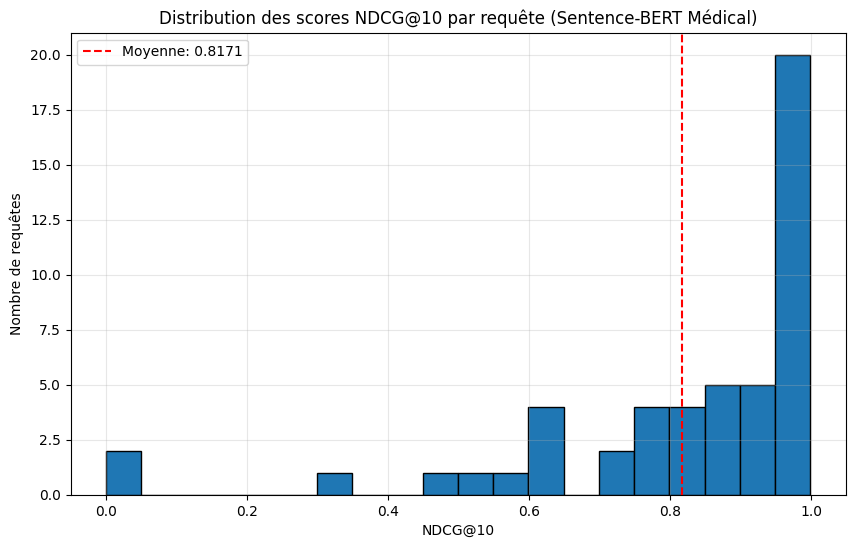

In [13]:
# Afficher la distribution des scores NDCG@10
ndcg_scores = evaluation_results['scores']

plt.figure(figsize=(10, 6))
plt.hist(list(ndcg_scores.values()), bins=20, edgecolor='black')
plt.xlabel('NDCG@10')
plt.ylabel('Nombre de requêtes')
plt.title('Distribution des scores NDCG@10 par requête (Sentence-BERT Médical)')
plt.axvline(evaluation_results['mean_score'], color='r', linestyle='--', 
            label=f'Moyenne: {evaluation_results["mean_score"]:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 📈 7. Analyse des Résultats


In [14]:
# Afficher les meilleures et pires requêtes
ndcg_df = pd.DataFrame([
    {'query_id': qid, 'ndcg@10': score} 
    for qid, score in ndcg_scores.items()
]).sort_values('ndcg@10', ascending=False)

print("Top 5 meilleures requêtes:")
print(ndcg_df.head())
print("\nTop 5 pires requêtes:")
print(ndcg_df.tail())


Top 5 meilleures requêtes:
   query_id   ndcg@10
47       48  0.998640
26       27  0.998640
48       49  0.998484
41       42  0.998241
19       20  0.997188

Top 5 pires requêtes:
   query_id   ndcg@10
31       32  0.501266
33       34  0.493702
0         1  0.315465
8         9  0.000000
46       47  0.000000


In [15]:
# Analyser une requête avec un bon score
best_query_id = ndcg_df.iloc[0]['query_id']
best_query_text = queries[best_query_id]
best_ndcg = ndcg_df.iloc[0]['ndcg@10']

print(f"\nRequête avec le meilleur NDCG@10 ({best_ndcg:.4f}):")
print(f"ID: {best_query_id}")
print(f"Texte: {best_query_text}\n")

# Obtenir les résultats du modèle pour cette requête
model_results = all_model_results[best_query_id]

print("Top 5 documents retournés:")
for i, (doc_id, score) in enumerate(model_results[:5], 1):
    doc = corpus[doc_id]
    relevance = qrels.get(best_query_id, {}).get(doc_id, 0)
    print(f"{i}. Doc {doc_id} (score Sentence-BERT: {score:.4f}, pertinence réelle: {relevance})")
    print(f"   Titre: {doc['title'][:80]}...")
    print()



Requête avec le meilleur NDCG@10 (0.9986):
ID: 48
Texte: what are the benefits and risks of re-opening schools in the midst of the COVID-19 pandemic?

Top 5 documents retournés:
1. Doc x6x6a35w (score Sentence-BERT: 0.9467, pertinence réelle: 2)
   Titre: COVID-19 Related School Closings and Risk of Weight Gain Among Children....

2. Doc 101aqyd5 (score Sentence-BERT: 0.9466, pertinence réelle: 2)
   Titre: Re-Opening Schools Safely: The Case for Collaboration, Constructive Disruption o...

3. Doc 4nv1kedt (score Sentence-BERT: 0.9460, pertinence réelle: 2)
   Titre: Children and the COVID-19 pandemic....

4. Doc 17a70tu9 (score Sentence-BERT: 0.9453, pertinence réelle: 2)
   Titre: Children and the COVID-19 pandemic...

5. Doc 5eg7hf6r (score Sentence-BERT: 0.9444, pertinence réelle: 2)
   Titre: COVID-19 and the re-opening of schools: a policy maker's dilemma...



## 💾 8. Sauvegarde des Résultats


In [16]:
# Sauvegarder les résultats pour comparaison avec BioWord2Vec et BioBERT
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# Sauvegarder les scores NDCG
ndcg_scores = evaluation_results['scores']
with open(f"{results_dir}/sentencebert_ndcg_scores.json", "w", encoding="utf-8") as f:
    json.dump(ndcg_scores, f, indent=2)

# Sauvegarder le résumé
summary = {
    "model": "Sentence-BERT_Medical",
    "model_name": model_name,
    "mean_ndcg@10": evaluation_results['mean_score'],
    "min_ndcg@10": evaluation_results['min_score'],
    "max_ndcg@10": evaluation_results['max_score'],
    "std_ndcg@10": evaluation_results['std_score'],
    "num_queries": evaluation_results['num_queries'],
    "num_documents": len(doc_ids),
    "embedding_dim": doc_vectors.shape[1]
}

with open(f"{results_dir}/sentencebert_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"✓ Résultats sauvegardés dans {results_dir}/")
print(f"  - sentencebert_ndcg_scores.json")
print(f"  - sentencebert_summary.json")


✓ Résultats sauvegardés dans results/
  - sentencebert_ndcg_scores.json
  - sentencebert_summary.json


## 🔬 9. Comparaison avec BioWord2Vec

Comparons les performances de Sentence-BERT avec BioWord2Vec.


In [17]:
# Charger les résultats de BioWord2Vec pour comparaison
biow2v_summary_path = f"{results_dir}/bioword2vec_summary.json"

if os.path.exists(biow2v_summary_path):
    with open(biow2v_summary_path, "r", encoding="utf-8") as f:
        biow2v_summary = json.load(f)
    
    print("=" * 70)
    print("COMPARAISON DES PERFORMANCES")
    print("=" * 70)
    print(f"\n{'Modèle':<30} {'NDCG@10':<15} {'Std':<15}")
    print("-" * 70)
    print(f"{'BioWord2Vec':<30} {biow2v_summary['mean_ndcg@10']:<15.4f} {biow2v_summary['std_ndcg@10']:<15.4f}")
    print(f"{'Sentence-BERT Médical':<30} {summary['mean_ndcg@10']:<15.4f} {summary['std_ndcg@10']:<15.4f}")
    
    improvement = summary['mean_ndcg@10'] - biow2v_summary['mean_ndcg@10']
    print("-" * 70)
    print(f"{'Amélioration':<30} {improvement:+.4f}")
    print("=" * 70)
    
    if improvement > 0:
        print(f"\n✅ Sentence-BERT améliore BioWord2Vec de {improvement:.4f} points")
        print("   Les embeddings optimisés pour la recherche fonctionnent mieux!")
    elif improvement < 0:
        print(f"\n⚠️ Sentence-BERT obtient {abs(improvement):.4f} points de moins que BioWord2Vec")
        print("   BioWord2Vec était déjà très adapté au domaine médical")
    else:
        print("\n➡️ Performances similaires")
else:
    print("⚠️ Fichier de résultats BioWord2Vec non trouvé.")
    print("   Exécutez d'abord bioword2vec.ipynb pour comparer les résultats.")


COMPARAISON DES PERFORMANCES

Modèle                         NDCG@10         Std            
----------------------------------------------------------------------
BioWord2Vec                    0.7366          0.3029         
Sentence-BERT Médical          0.8171          0.2305         
----------------------------------------------------------------------
Amélioration                   +0.0804

✅ Sentence-BERT améliore BioWord2Vec de 0.0804 points
   Les embeddings optimisés pour la recherche fonctionnent mieux!
